## Overview
EDAでいろいろ試してみる。

In [51]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')

- trainデータ件数: 691369
- testデータ件数 : 296302

欠損はたくさん。IDとラベル以外の全カラムにいる。

カラムの説明はないので予想してみる。（あとでDiscussionとかで確認しよう）
|column|note|
|---|---|
|id|id|
|age|年齢|
|daily_screen_time_hours|普段画面を見ている時間|
|social_media_hours|ソーシャルメディアに触れている時間（SNSとかYOUTUBE?）|
|gaming_hours|ゲームしてる時間|
|work_study_hours|仕事、勉強している時間（スマホで？スマホ以外で？） → MAXが6だから、スマホで、かも|
|sleep_hours|睡眠時間|
|notifications_per_day|1日に何件の通知を受け取るか|
|app_opens_per_day|1日に何回アプリを開くか|
|weekend_screen_time|週末に画面を見ている時間|
|gender|性別|
|stress_level|どれくらいストレスを感じているか|
|academic_work_impact|学術的な仕事・活動の影響|
|addicted_label|依存判定（trainだけ）|

あとこれは「合成データ」といって、人工的に作られた人たちのデータらしい。

In [52]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  str    
 11  stress_level             636221 non-null  str    
 12  academic_work_impact     647145 non-null  str    
 13  addicted_label           691369 non-null  int64  
dtypes: float64(9), 

In [53]:
train_df.head()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


In [54]:
train_df.describe()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,691369.000000,662440.000000,595515.000000,557374.000000,564548.000000,639851.000000,646889.000000,623785.000000,610659.000000,579306.000000,691369.000000
mean,345684.000000,26.615408,7.640865,2.471038,1.459265,2.366971,6.804334,145.894900,102.636781,9.479866,0.709424
std,199581.183467,5.153162,2.721446,1.316137,0.934552,1.258797,1.234512,65.917556,48.093970,2.856006,0.454028
min,0.000000,18.000000,0.500000,0.000000,0.000000,0.000000,4.500000,20.000000,15.000000,0.510000,0.000000
25%,172842.000000,22.000000,5.480000,1.450000,0.700000,1.360000,5.780000,93.000000,64.000000,7.280000,0.000000
50%,345684.000000,27.000000,7.770000,2.310000,1.330000,2.200000,6.800000,150.000000,104.000000,9.580000,1.000000
75%,518526.000000,31.000000,9.840000,3.370000,2.090000,3.200000,7.870000,204.000000,145.000000,11.750000,1.000000
max,691368.000000,35.000000,15.000000,8.000000,4.000000,6.000000,9.000000,250.000000,180.000000,17.560000,1.000000


In [55]:
train_df["gender"].unique()

<StringArray>
['Male', 'Female', 'Other', nan]
Length: 4, dtype: str

In [56]:
train_df["stress_level"].unique()

<StringArray>
['Medium', 'Low', 'High', nan]
Length: 4, dtype: str

In [57]:
train_df.isnull().sum()

id                              0
age                         28929
daily_screen_time_hours     95854
social_media_hours         133995
gaming_hours               126821
work_study_hours            51518
sleep_hours                 44480
notifications_per_day       67584
app_opens_per_day           80710
weekend_screen_time        112063
gender                      29034
stress_level                55148
academic_work_impact        44224
addicted_label                  0
dtype: int64

年齢はあまり関係なさそう。

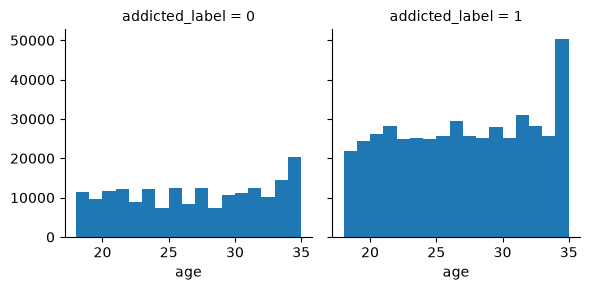

In [58]:
g = sns.FacetGrid(train_df, col='addicted_label')
g.map(plt.hist, 'age', bins=17)

In [59]:
train_df.groupby('addicted_label')['age'].describe()

,count,mean,std,min,25%,50%,75%,max
addicted_label,,,,,,,,
0,192604.0,26.582864,5.24962,18.0,22.0,27.0,31.0,35.0
1,469836.0,26.628749,5.11304,18.0,22.0,27.0,31.0,35.0


睡眠時間も単体では相関がなさそう。これは意外。

他の何かと組み合わせて使えないものか・・・。

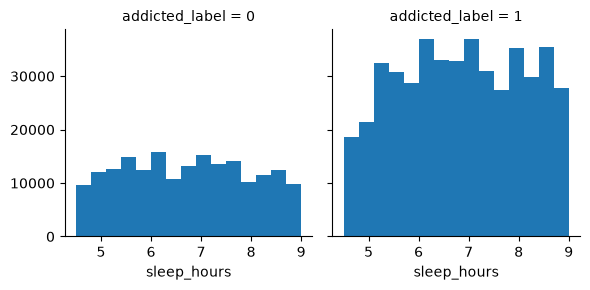

In [60]:
g = sns.FacetGrid(train_df, col='addicted_label')
g.map(plt.hist, 'sleep_hours', bins=15)

In [61]:
train_df.groupby('addicted_label')['sleep_hours'].describe()

,count,mean,std,min,25%,50%,75%,max
addicted_label,,,,,,,,
0,188146.0,6.722321,1.239769,4.5,5.66,6.72,7.74,9.0
1,458743.0,6.837970,1.230772,4.5,5.83,6.84,7.91,9.0


明らかに相関がある。いい特徴量みっけ！

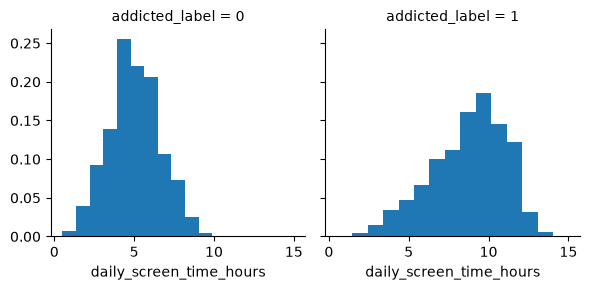

In [62]:
g = sns.FacetGrid(train_df, col='addicted_label')
g.map(plt.hist, 'daily_screen_time_hours', bins=15, density=True)

In [63]:
train_df.groupby('addicted_label')['daily_screen_time_hours'].describe()

,count,mean,std,min,25%,50%,75%,max
addicted_label,,,,,,,,
0,173222.0,5.042929,1.620399,0.5,3.96,5.04,6.16,13.32
1,422293.0,8.706523,2.337327,0.5,7.21,9.07,10.46,15.00


直感通り、通知がたくさん来ると依存傾向にあるみたい。

→ と思ったのもつかの間、どうやら人数が多かっただけみたい。

`density=True`をつけると割合でみれるぞ。

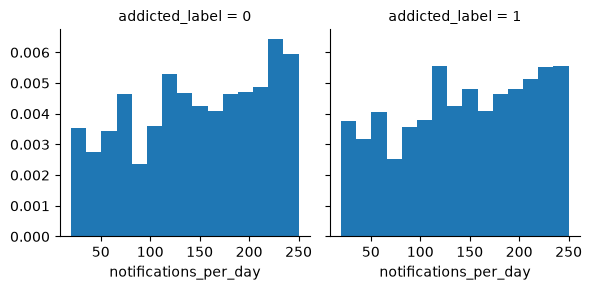

In [64]:
g = sns.FacetGrid(train_df, col='addicted_label')
g.map(plt.hist, 'notifications_per_day', bins=15, density=True)

**なぜ最初からこれを確認しなかったのか。知らなかったのだ。**

`daily_screentime, social_media_hours, work_study_hours, weekend_screen_hours`

まずはこのへんをFeaturesにしてベースラインを作ってみることにした。

In [70]:
train_df.groupby('addicted_label').mean(numeric_only=True)

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time
addicted_label,,,,,,,,,,
0,345341.753194,26.582864,5.042929,1.376144,1.159677,1.872582,6.722321,147.087661,97.871440,6.848920
1,345824.182093,26.628749,8.706523,2.919495,1.582119,2.569566,6.837970,145.406142,104.592844,10.558729


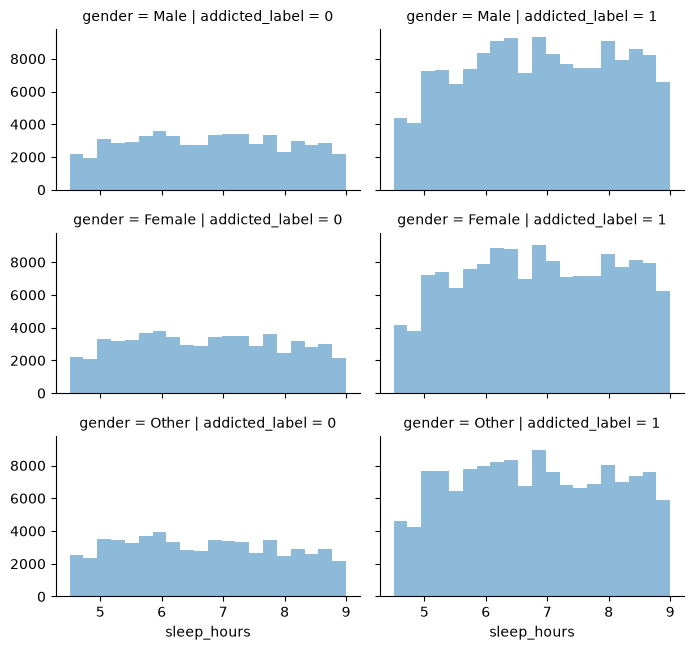

In [65]:
g = sns.FacetGrid(train_df, col='addicted_label', row='gender', height=2.2, aspect=1.6)
g.map(plt.hist, 'sleep_hours', alpha=0.5, bins=20)